# RMSX Demonstration

This notebook includes everything you need to run **RMSX** and **Flipbook**. Just run each cell. You are encouraged to try different parameters and use your own trajectories directly within this notebook or by making a copy of it.


We'll cover:

1. Environment setup
2. Loading demo input files
3. Single-chain RMSX
4. Multi-chain RMSX
5. FlipBook snapshots (optional)
6. Interpreting results

> **Note:** Adjust file paths as needed for your machine. We reccomend not editing the first two cells, though.

## 1) Environment Setup

- **R** — used for heatmaps and RMSD/RMSF plots via `Rscript`.
- **ChimeraX** (optional) — used for FlipBook image generation.


### Quick Start

In [2]:
# One-click install for this kernel (no sudo; no Plotly required)
import sys, os, site, tempfile, urllib.request, subprocess, shutil

def _ensure_pip_in_kernel():
    try:
        import pip  # noqa: F401
        return
    except Exception:
        pass
    # Bootstrap pip into THIS kernel if it's missing
    print("Bootstrapping pip into this Jupyter kernel…")
    with tempfile.TemporaryDirectory() as td:
        gp = os.path.join(td, "get-pip.py")
        urllib.request.urlretrieve("https://bootstrap.pypa.io/get-pip.py", gp)
        subprocess.check_call([sys.executable, gp, "--user"])
    # Make sure user-site is importable in this process
    us = site.getusersitepackages()
    if us not in sys.path:
        sys.path.append(us)

_ensure_pip_in_kernel()

# Use Jupyter's %pip so installs target THIS kernel

%pip install -U pip wheel setuptools
%pip install -U "numpy>=1.26,<2.0" "pandas>=2.2,<2.3" "MDAnalysis>=2.6,<3" "scipy>=1.10" "plotly>=5"
%pip install -U "git+https://github.com/AntunesLab/rmsx.git@main" plotly>=5

# Optional: show Rscript (for plots) if available
import subprocess
RSCRIPT = os.environ.get("RSCRIPT", "Rscript")
try:
    out = subprocess.run([RSCRIPT, "-e", "cat(R.version.string)"] , capture_output=True, text=True)
    print(out.stdout or out.stderr or "Rscript OK")
except FileNotFoundError:
    print("⚠️ Rscript not found. Heatmap/RMSD/RMSF plots will be skipped until R is installed or RSCRIPT is set.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 29.6 MB/s  0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 82.0.0
    Uninstalling setuptools-82.0.0:
      Successfully uninstalled setuptools-82.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda 23.7.4 requires ruamel-yaml<0.18,>=0.11.14, but you have ruamel-yaml 0.18.6 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
zsh:1: 5 not found
Note: you may need to restart the kernel to use updated packages.
R version 4.5.1 (2025-06-13)


In [3]:
# Imports & locate sample data
from pathlib import Path
import os, subprocess

from rmsx import run_rmsx, run_rmsx_flipbook, all_chain_rmsx, run_shift_flipbook
import rmsx

pkg_dir = Path(rmsx.__file__).resolve().parent

# Optional: set this to use your own dataset folder
# os.environ["RMSX_TEST_DIR"] = "/path/to/test_files"
env_override = os.environ.get("RMSX_TEST_DIR")

candidates = []
if env_override:
    candidates.append(Path(env_override))

candidates += [
    Path.cwd() / "test_files",              # next to this notebook
    Path.cwd() / "rmsx" / "test_files",     # if you cloned into ./rmsx
    pkg_dir / "test_files",                 # packaged tests (if included)
    pkg_dir.parent / "test_files",          # repo layout when running from source
]

test_dir = next((p for p in candidates if p.exists()), None)

# Last resort: clone repo to fetch sample data (does not affect installed package)
if not test_dir:
    REPO_URL = "https://github.com/AntunesLab/rmsx.git"
    REPO_DIR = Path.cwd() / "rmsx"
    if not REPO_DIR.exists():
        print("Cloning RMSX repo to retrieve sample data…")
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])
    test_dir = REPO_DIR / "test_files"
    if not test_dir.exists():
        raise FileNotFoundError("Couldn't locate test_files after cloning. Please report this issue.")

# Single-chain demo (Ubiquitin)
pdb_file   = (test_dir / "1UBQ.pdb").as_posix()
dcd_file   = (test_dir / "mon_sys.dcd").as_posix()
output_dir = (test_dir / "example_uqb").as_posix()

# Multi-chain demo (protease) — files live directly under test_files/
pdb_file_multi   = (test_dir / "protease_backbone.pdb").as_posix()
traj_file_multi  = (test_dir / "short_protease_backbone.dcd").as_posix()
output_dir_multi = (test_dir / "protease").as_posix()

print("Single-chain inputs:")
print("  PDB:", pdb_file)
print("  DCD:", dcd_file)
print("  out:", output_dir)

print("\nMulti-chain inputs:")
print("  PDB:", pdb_file_multi)
print("  DCD:", traj_file_multi)
print("  out:", output_dir_multi)


Single-chain inputs:
  PDB: /Users/finn/Documents/GitHub/rmsx/test_files/1UBQ.pdb
  DCD: /Users/finn/Documents/GitHub/rmsx/test_files/mon_sys.dcd
  out: /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb

Multi-chain inputs:
  PDB: /Users/finn/Documents/GitHub/rmsx/test_files/protease_backbone.pdb
  DCD: /Users/finn/Documents/GitHub/rmsx/test_files/short_protease_backbone.dcd
  out: /Users/finn/Documents/GitHub/rmsx/test_files/protease


*Windows users: if R isn’t on PATH, set `RSCRIPT` before running:*

In [4]:
import os
# os.environ["RSCRIPT"] = r"C:\\Program Files\\R\\R-4.4.1\\bin\\Rscript.exe"  # <- edit if needed
!pwd

/Users/finn/Documents/GitHub/rmsx


## 2) Load Demo Input Files

These come with the package as `test_files`. Rather than editing these we recocomend adding your paths in later cells.

## 3) Single-Chain RMSX

`run_rmsx` computes per-slice RMSX and generates:
- RMSX heatmap
- RMSD time series
- RMSF per-residue

Edit `palette` and `chain_sele` as needed. (For the included Ubiquitin demo, the chain is `"7"`.)

In [5]:
print(pdb_file,dcd_file, output_dir)

/Users/finn/Documents/GitHub/rmsx/test_files/1UBQ.pdb /Users/finn/Documents/GitHub/rmsx/test_files/mon_sys.dcd /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb


Please cite RMSX + Flipbook:
Beruldsen, F., de Freitas, M.V. & Antunes, D.A. High resolution mapping of protein motions in time and space with RMSX and Flipbook. Sci Rep (2026). https://doi.org/10.1038/s41598-026-39869-7
Python Executable: /Users/finn/Library/r-miniconda-arm64/bin/python
Current Working Directory: /Users/finn/Documents/GitHub/rmsx
Overwriting existing directory: /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx
The directory '/Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx' is ready for use.
Starting analysis...
Using the slicing method with num_slices=9
Truncating 1 excess frame(s). Original size: 316, Updated: 315
Processing frames 0 to 314 of the trajectory.
Number of slices: 9
First frame of slice 1 written to /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_1_first_frame.pdb
Slice 1: RMSF computed for frames 0 to 34 (35 frames)
First frame of slice 2 written to /Users/finn/Documents/GitHub/rmsx/t

/Users/finn/Library/r-miniconda-arm64/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_1_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_2_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_3_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_4_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_5_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_6_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_7_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/GitHub/rmsx/test_files/example_uqb/chain_7_rmsx/slice_8_first_frame.pdb
Updated PDB B-factors in /Users/finn/Documents/G

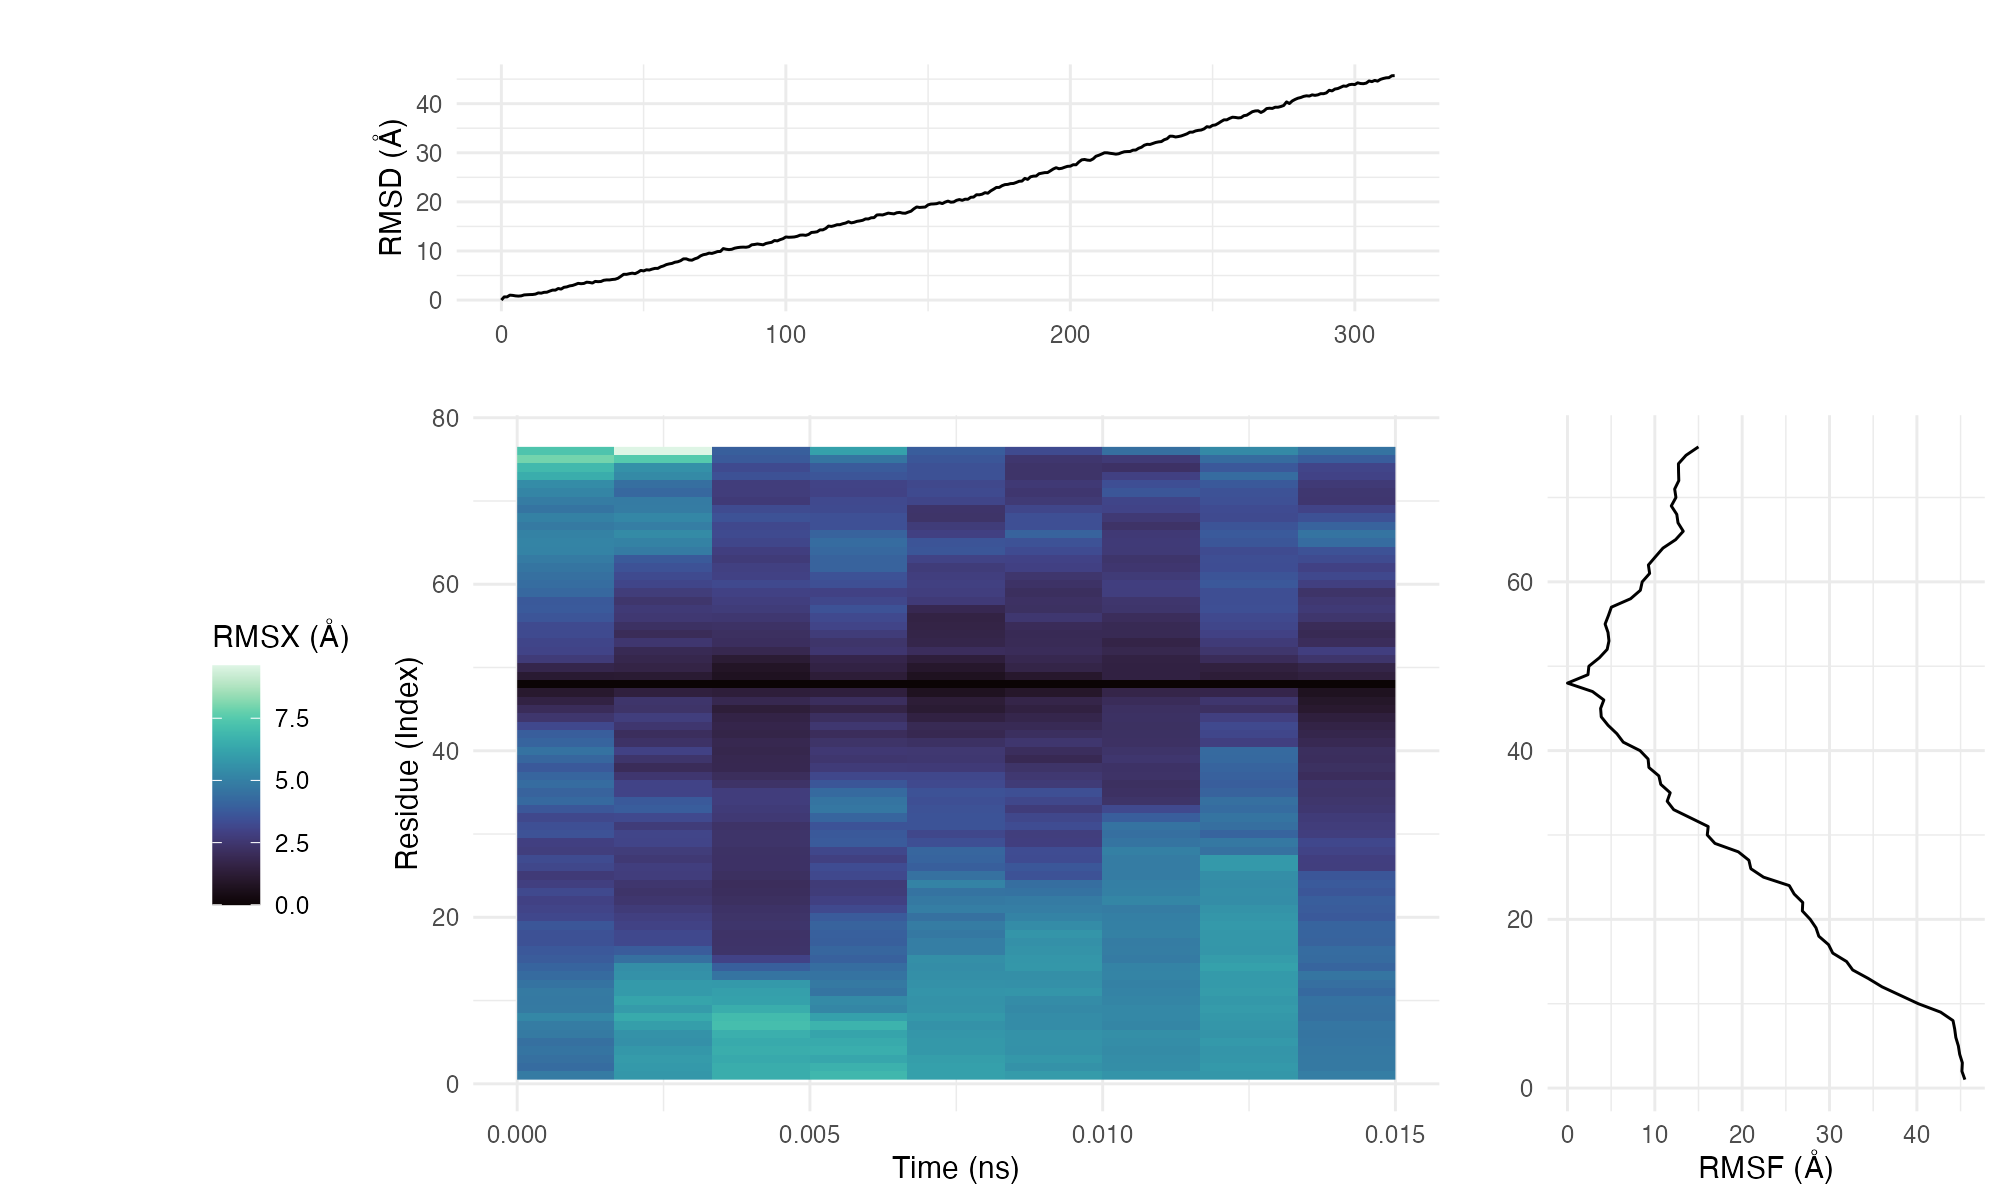


Now summarizing the top 3 and bottom 3 RMSX values...

===== Top 3 RMSX values across all slices =====
TimeSlice: slice_2.dcd, ChainID: 7, ResidueID: 76, RMSX: 9.616
TimeSlice: slice_1.dcd, ChainID: 7, ResidueID: 75, RMSX: 7.957
TimeSlice: slice_2.dcd, ChainID: 7, ResidueID: 75, RMSX: 7.496

===== Bottom 3 RMSX values across all slices =====
TimeSlice: slice_1.dcd, ChainID: 7, ResidueID: 48, RMSX: 0.000
TimeSlice: slice_2.dcd, ChainID: 7, ResidueID: 48, RMSX: 0.000
TimeSlice: slice_3.dcd, ChainID: 7, ResidueID: 48, RMSX: 0.000



(     ResidueID  ChainID    TimeSlice      RMSX
 151         76        7  slice_2.dcd  9.616028
 74          75        7  slice_1.dcd  7.957497
 150         75        7  slice_2.dcd  7.495831,
      ResidueID  ChainID    TimeSlice  RMSX
 47          48        7  slice_1.dcd   0.0
 123         48        7  slice_2.dcd   0.0
 199         48        7  slice_3.dcd   0.0)

In [6]:
from rmsx import *



run_rmsx(
    topology_file=pdb_file,        # PDB or topology file
    trajectory_file=dcd_file,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=9,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,               # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="mako",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="7",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=False
)


In [ ]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.exceptions import SelectionError

# also verify that this isn't an MDA issue if this doesn't work the problem is with MDA:

dcd_file = "/Users/amit/Documents/research_projects/mdrepo/test/min_new.xtc"
topology_file = "/Users/amit/Documents/research_projects/mdrepo/test/min.pdb"

#if this throws an error it is an MDA issue not an RMSX issue
u = mda.Universe(topology_file, dcd_file)



print("MDAnalysis version:", mda.__version__)
print("Unique segids in this topology:")
segids = np.unique(u.atoms.segids)
print([repr(s) for s in segids])

print("\nTesting selections of the form 'segid <value>':")
for s in segids:
    sel_str = f"segid {s}"
    print(f"  Trying: {sel_str!r}")
    try:
        ag = u.select_atoms(sel_str)
        print(f"    OK, selected {ag.n_atoms} atoms")
    except SelectionError as e:
        print(f"    SelectionError: {e}")



"""
If it runs and it says something like

MDAnalysis version: 2.9.0
Unique segids in this topology:
["'7'"]

Testing selections of the form 'segid <value>':
  Trying: 'segid 7'
    OK, selected 1231 atoms

Then the system is working fine and there is a problem with RMSX's handling of some kind of edge case we haven't encounter.
ed (please feel free to reach out or open an issue)

If it returns multiple empty lists like ["'7' 'None' ''"] or anything else strange - there maybe something off with how the PDB file is written or some disagreement inbetween the xtc and the pdb file.

"""



In [ ]:
import MDAnalysis as mda

from rmsx.core import run_rmsx

# --- paths: your working example ---
pdb_ok = "/Users/finn/Documents/GitHub/rmsx/test_files/1UBQ.pdb"
dcd_ok = "/Users/finn/Documents/GitHub/rmsx/test_files/mon_sys.dcd"
outdir_base = "/Users/finn/Documents/GitHub/rmsx/test_files/rmsx_debug"

def run_case(pdb_file, traj_file, label):
    print(f"\n=== Running case: {label} ===")
    print(f"PDB:  {pdb_file}")
    print(f"TRAJ: {traj_file}")
    try:
        run_rmsx(
            topology_file=pdb_file,
            trajectory_file=traj_file,
            output_dir=f"{outdir_base}_{label}",
            num_slices=9,
            slice_size=None,
            rscript_executable="Rscript",
            verbose=True,
            interpolate=False,
            triple=True,
            overwrite=True,
            palette="mako",
            chain_sele="7",
            start_frame=0,
            end_frame=None
        )
        print(f"Case {label}: SUCCESS")
    except Exception as e:
        print(f"Case {label}: ERROR -> {type(e).__name__}: {e}")
        raise

# sanity check: working base case
run_case(pdb_ok, dcd_ok, "base_ok")


In [ ]:
import MDAnalysis as mda
from MDAnalysis.exceptions import SelectionError

pdb_file = "/Users/finn/Documents/GitHub/rmsx/test_files/1UBQ_segid_None.pdb"
dcd_file = "/Users/finn/Documents/GitHub/rmsx/test_files/mon_sys.dcd"

u = mda.Universe(pdb_file, dcd_file)

print("MDAnalysis version:", mda.__version__)
print("Segments (segid, n_atoms):")
for seg in u.segments:
    print(f"  {repr(seg.segid)}  n_atoms={seg.atoms.n_atoms}")

print("\nTesting selection strings:\n")

tests = [
    "segid None",
    "segid A",
    "segid 7",
    "segid",          # obviously invalid
    "segid  ",        # degenerate
    "name None",
    "name  ",         # this often triggers 'Unexpected token None' on some versions
]

for s in tests:
    print(f"Selection: {repr(s)}")
    try:
        ag = u.select_atoms(s)
        print("  OK, selected", len(ag), "atoms\n")
    except Exception as e:
        print("  ERROR:", type(e).__name__, e, "\n")


In [ ]:
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=20,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,               # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="B",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=False

)


In [ ]:
run_shift_flipbook(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=output_dir,
    num_slices=8,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=150,
    sync_color_scale=True,           # Useful when chains have very different RMSX values, True will force the same color key/scale to be used
    viewer="vmd"
)


In [ ]:
!Rscript -e 'user<-Sys.getenv("R_LIBS_USER"); if(user=="") user<-file.path(Sys.getenv("HOME"),"R","library"); dir.create(user,recursive=TRUE,showWarnings=FALSE); .libPaths(c(user,.libPaths())); install.packages(c("ggplot2","viridis","dplyr","tidyr","stringr","readr","gridExtra"), lib=user, dependencies=c("Depends","Imports","LinkingTo"))'


## 4) Multi-Chain RMSX

`all_chain_rmsx` runs RMSX for **every** chain in the topology. If you set `sync_color_scale=True`,
all plots share a consistent colorbar range.

In [ ]:
all_chain_rmsx(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=output_dir,
    num_slices=12,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=None,
    sync_color_scale=True           # Useful when chains have very different RMSX values, True will force the same color key/scale to be used
)

In [ ]:
all_chain_rmsx(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir,
    num_slices=12,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=None,
    window_check=True,
    sync_color_scale=True  # Useful when chains have very different RMSX values, True will force the same color key/scale to be used

)

## 5) FlipBook (optional)

FlipBook maps RMSX values (stored in the PDB B-factor column) onto 3D structures and lays out snapshots side-by-side.

In [ ]:
run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="magma",         # automatically matches color palette for heatmap and chimeraX structures
    spacingFactor="0.9",     # how much space between the snapshots; 1 is default
    start_frame=0,
    end_frame=None
)

### 5.1 Display the latest FlipBook image (if generated)
If you don't like the orientation, try adjusting it in ChimeraX and rerunning the save command (see the ChimeraX log for details)

/Users/finn/Library/r-miniconda-arm64/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


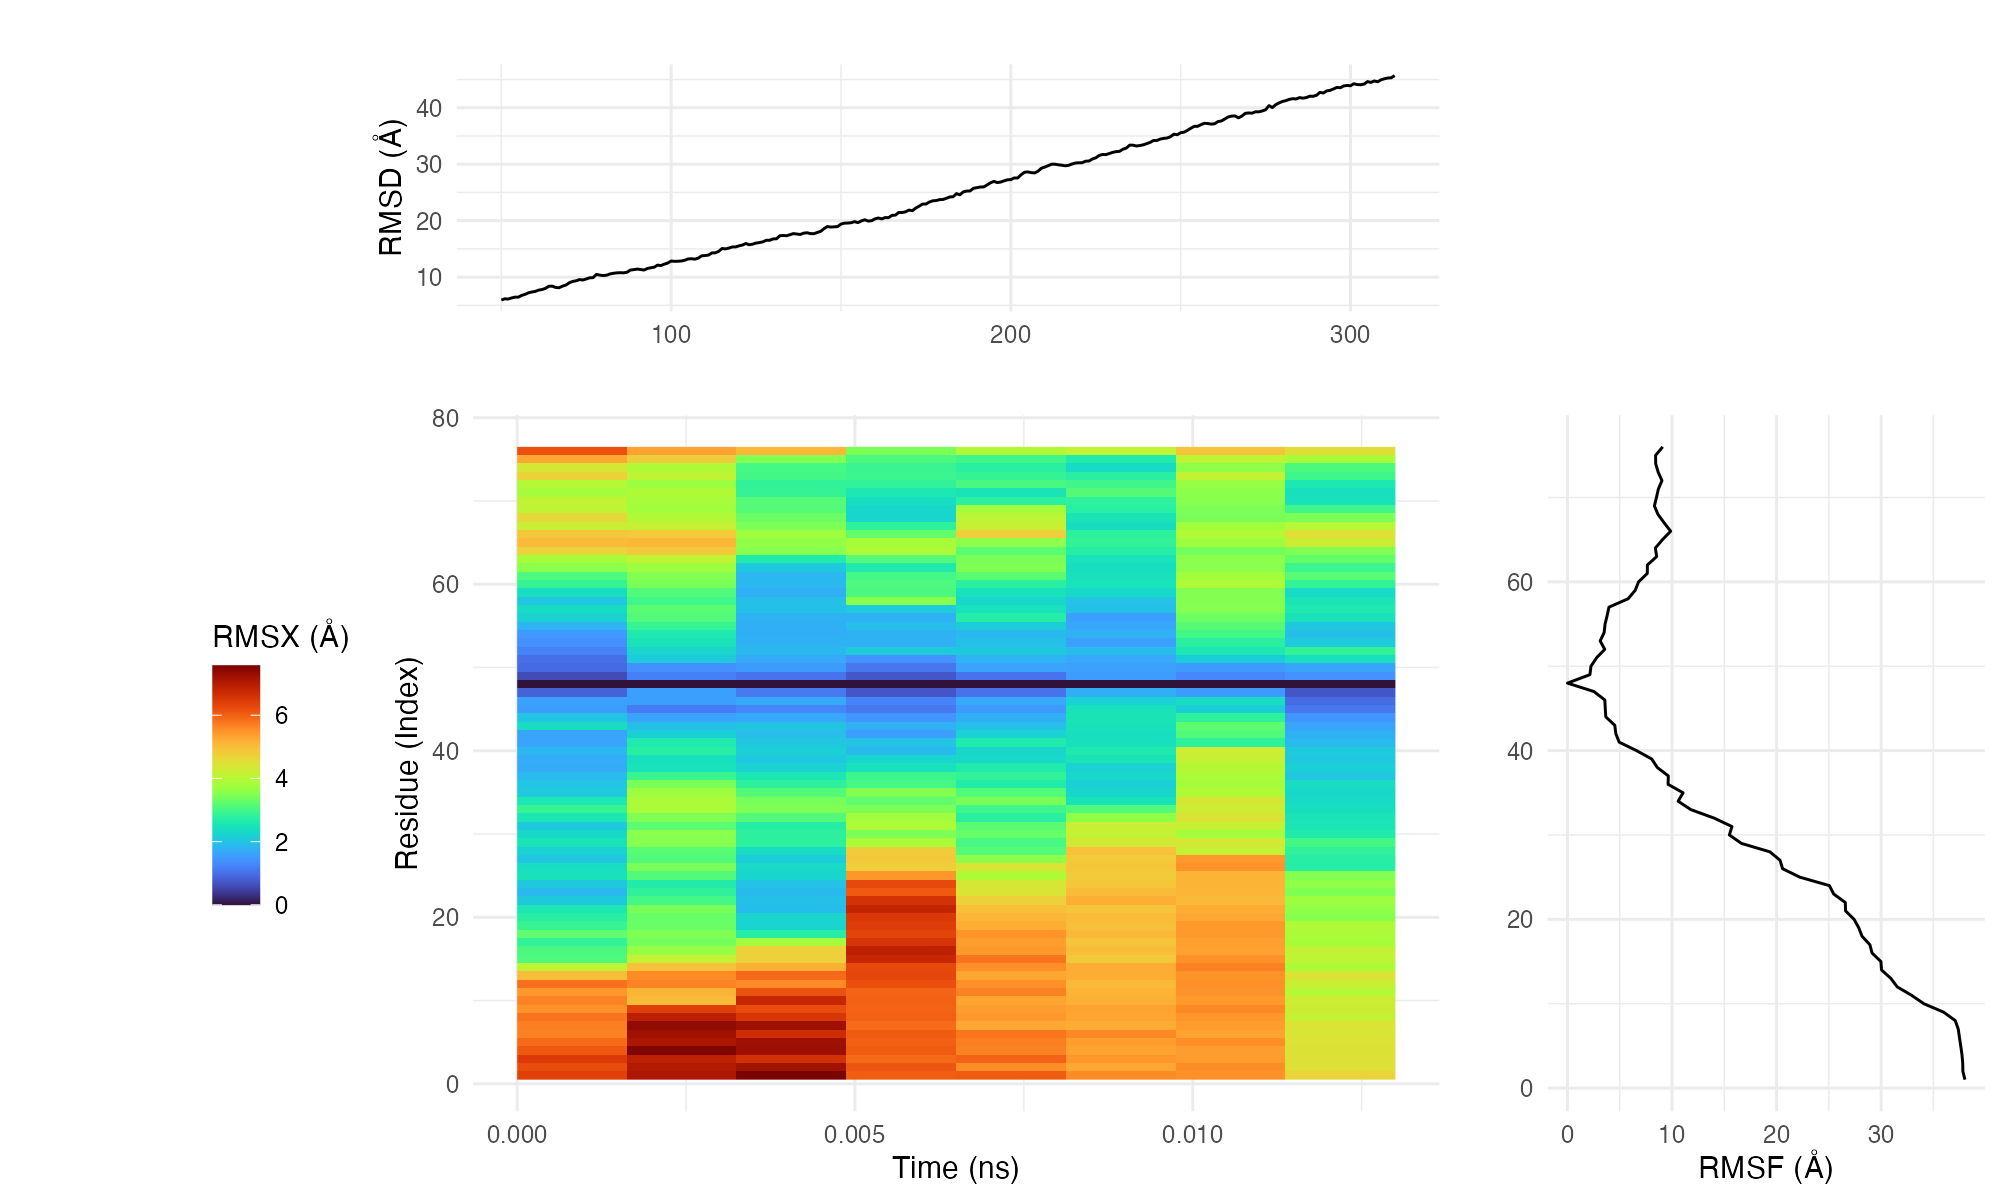

Detected B-factor range: 0.00 - 7.57
[flipbook] macOS bundle candidates (sorted):
   - ChimeraX-1.10.1.app -> /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX  (ver=1.10.1, daily=False)
   - ChimeraX-1.8.app -> /Applications/ChimeraX-1.8.app/Contents/MacOS/ChimeraX  (ver=1.8, daily=False)
   - ChimeraX-1.5.app -> /Applications/ChimeraX-1.5.app/Contents/MacOS/ChimeraX  (ver=1.5, daily=False)
   - ChimeraX_Daily.app -> /Applications/ChimeraX_Daily.app/Contents/MacOS/ChimeraX  (ver=0, daily=True)
[flipbook] Checking ChimeraX candidates (in order):
   - macOS app bundle (ChimeraX-1.10.1.app): /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Using ChimeraX installation: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX
[flipbook] Launching: /Applications/ChimeraX-1.10.1.app/Contents/MacOS/ChimeraX


2026-03-09 22:19:15.868 ChimeraX[93095:7693838] TSMSendMessageToUIServer: CFMessagePortSendRequest FAILED(-1) to send to port com.apple.tsm.uiserver


In [15]:
run_rmsx_flipbook(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=output_dir,
    num_slices=8,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    spacingFactor="0.9",
    start_frame=50,
    end_frame=None,   # <--- THIS IS THE ONLY CHANGE
    viewer="chimerax"
)


/Users/finn/Library/r-miniconda-arm64/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/Users/finn/Library/r-miniconda-arm64/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


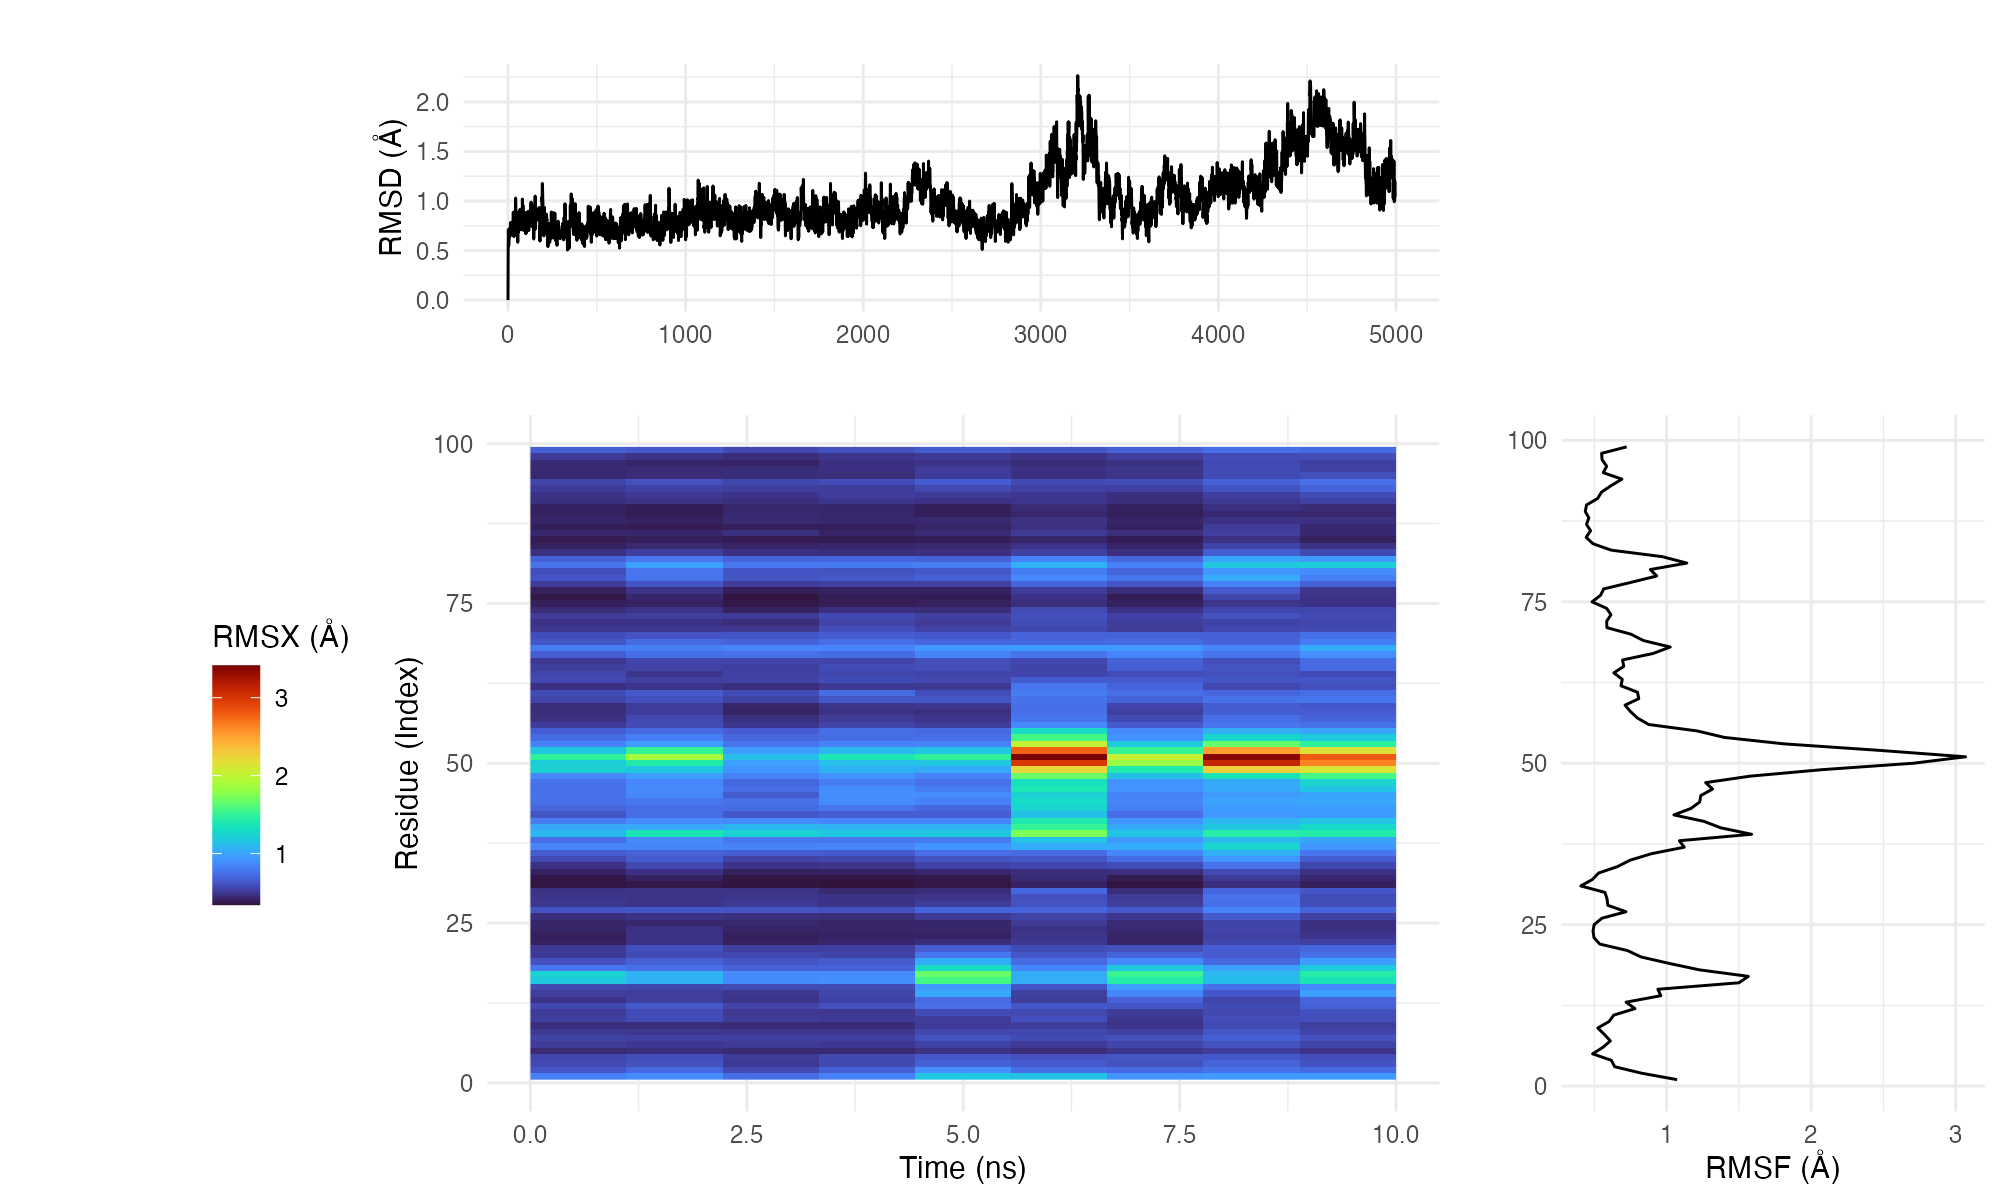

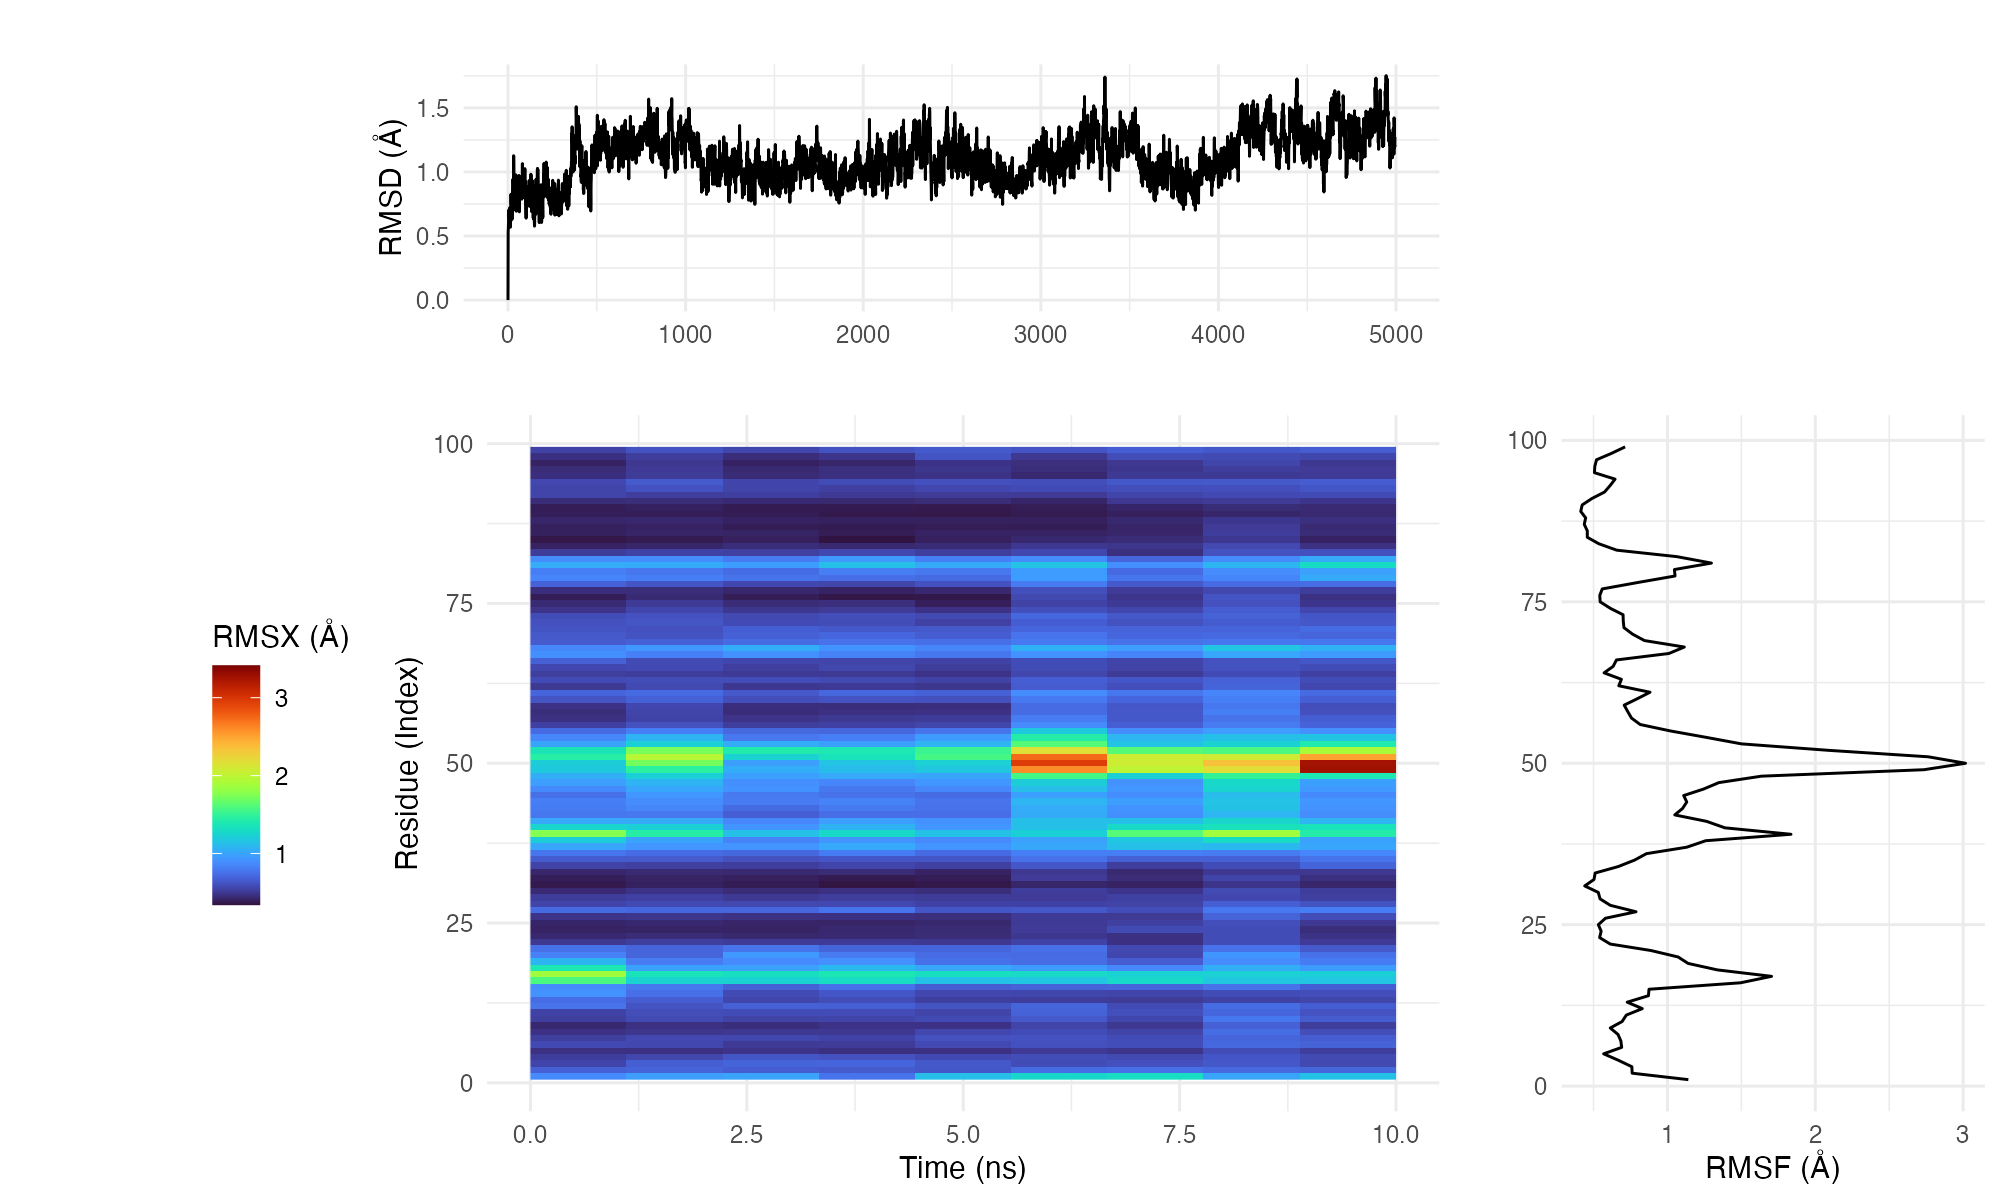

Detected B-factor range: 0.34 - 3.41
[flipbook] Using VMD backend (PTY Mode)...
[flipbook] Launching VMD in PTY:
  /Applications/VMD 2.0.0a7-pre2.app/Contents/vmd2/lib/vmd_MACOSXARM64 -dispdev win -e /Users/finn/Documents/GitHub/rmsx/rmsx/vmd_scripts/wait_to_load.tcl -args /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_1_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_2_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_3_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_4_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_5_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_6_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_7_first_frame.pdb /Users/finn/Documents/GitHub/rmsx/test_files/protease/combined/slice_8_first_frame.pdb /Users/finn/Documents/GitHub/r

In [7]:
run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    manual_length_ns="10",
    palette="turbo",
    spacingFactor="0.9",
    start_frame=0,
    end_frame=None,   # <--- THIS IS THE ONLY CHANGE
    viewer="vmd"
)


In [ ]:
import glob
from IPython.display import Image, display
imgs = sorted(glob.glob(os.path.join(output_dir_multi, "combined", "*.png")))
if imgs:
    display(Image(filename=imgs[-1]))
else:
    print("No flipbook images found in:", os.path.join(output_dir_multi, "combined"))

### 5.2 Using VMD for FlipBook Visualization
Newer Versions of RMSX/Flipbook support VMD as an alternative to ChimeraX for generating images. To use VMD, set `viewer="vmd"` in the `run_rmsx_flipbook` call. This is still a new feature and may not work on windows machines. You can always visualize them directly with vmd by running something like:

`
$ vmd -dispdev win -e wait_to_load.tcl -args \
path/to/file/slice_1_first_frame.pdb \
path/to/file/slice_2_first_frame.pdb \
path/to/file/slice_3_first_frame.pdb \
path/to/file/slice_4_first_frame.pdb
`

The wait_to_load.tcl script can help solve the issues of VMD loading too quickly before all files are ready. You can also directly call `grid_color_scale_centered_xaxis_hotkeys.tcl`.

Both are located in the vmd_scripts directory.

Check the tcl console for tips on how to adjust the spacing and rotation with VMD hotkeys.

VMD supports extremely high quality rendering with Tachyon.
See the [VMD documentation](https://www.ks.uiuc.edu/Research/vmd/minitutorials/tachyonao/) for details.

In [ ]:

run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=16,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",         # automatically matches color palette for heatmap and chimeraX structures
    spacingFactor="0.9",     # how much space between the snapshots; 1 is default
    start_frame=0,
    end_frame=None,
    viewer="ChimeraX"
)

## 6) Interpreting Results

If you want the flanking plots, `triple=True`, RMSX produces:
- **RMSX heatmap** (residue × time slice)
- **RMSD** over time
- **RMSF** per residue

**Questions to ask:**
1. Which residues/regions show the most flexibility?
2. When do flexibility spikes occur (early/mid/late)?
3. Do multiple intervals of high fluctuation appear?
4. How do these align with functional domains or events (e.g., binding, domain motion)?

---
### Conclusions

You’ve seen how to:
1. Install and configure **RMSX** and **Flipbook**
2. Run single- and multi-chain analyses
3. Generate FlipBook snapshots (optional)
4. Interpret RMSX plots (when/where the biggest changes happen)

For more details, visit the GitHub repo or open an issue with questions.

Feel free to email the primary developer Finn Beruldsen at fpberuld@cougarnet.uh.edu if you need anything else.


### Acknowledgements
We thank the following beta tests for their valuable feedback on this tutorial:
- Mason Kretiv — Texas A&M University
- Helen Ashdown — NIH Biowulf
- John Miles — University of Missouri

In [ ]:
## 3b) Single-Chain lDDT (optional)

from rmsx.addons.lddt import run_lddt_map, run_lddt_flipbook, all_chain_lddt_map

# Put lDDT outputs next to the existing RMSX example
lddt_output_dir = (test_dir / "example_uqb_lddt").as_posix()

run_lddt_map(
    topology_file=pdb_file,  # same PDB as RMSX demo
    trajectory_file=dcd_file,  # same trajectory
    output_dir=lddt_output_dir,  # new folder for lDDT outputs
    num_slices=9,  # same slicing pattern as RMSX demo
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,  # lDDT heatmap + RMSD + RMSF
    overwrite=True,
    palette="viridis",  # choose your favorite cmap
    chain_sele="7",  # same chain as RMSX demo
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    summary_n=3,
    manual_length_ns=None,
    log_transform=False,  # lDDT is already 0–1
    inclusion_radius=15.0,  # local neighborhood radius (Å)
    thresholds=(0.5, 1.0, 2.0, 4.0),  # classic lDDT thresholds

)






In [ ]:
## 4b) Multi-Chain lDDT Maps (protease)

# New output folder for multi-chain lDDT (keep separate from RMSX/shift outputs)
lddt_output_dir_multi = (test_dir / "protease_lddt").as_posix()

combined_lddt_dir = all_chain_lddt_map(
    topology_file=pdb_file_multi,  # protease backbone
    trajectory_file=traj_file_multi,  # short_protease_backbone.dcd
    output_dir=lddt_output_dir_multi,
    num_slices=12,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",
    start_frame=0,
    end_frame=None,
    sync_color_scale=True,  # shared colorbar across chains
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    log_transform=False,
    inclusion_radius=15.0,
    thresholds=(0.5, 1.0, 2.0, 4.0),
)

print("Combined lDDT PDBs for Flipbook live in:", combined_lddt_dir)


In [ ]:
## 5b) Multi-Chain lDDT Flipbook (protease)

# Same idea as the run_rmsx_flipbook demo, but using lDDT instead of RMSX
run_lddt_flipbook(
    topology_file=pdb_file,
    trajectory_file=dcd_file,
    output_dir=lddt_output_dir_multi,  # same parent as above
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="inferno",  # matches lDDT heatmap
    spacingFactor="0.9",  # spacing between tiled models
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    sync_color_scale=True,  # enforce global lDDT scale
    flipbook_min_bfactor=None,  # auto-scale unless you want fixed
    flipbook_max_bfactor=None,
    log_transform=False,
    inclusion_radius=15.0,
    thresholds=(0.5, 1.0, 2.0, 4.0),
    viewer="chimerax",  # or "ChimeraX" / "chimerax"
    extra_commands=None,  # e.g. extra ChimeraX commands
)


In [ ]:
## 5b) Multi-Chain lDDT Flipbook (protease)

# Same idea as the run_rmsx_flipbook demo, but using lDDT instead of RMSX
run_lddt_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=lddt_output_dir_multi,  # same parent as above
    num_slices=20,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # matches lDDT heatmap
    spacingFactor="0.9",  # spacing between tiled models
    start_frame=200,
    end_frame=None,
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    sync_color_scale=True,  # enforce global lDDT scale
    flipbook_min_bfactor=None,  # auto-scale unless you want fixed
    flipbook_max_bfactor=None,
    log_transform=False,
    inclusion_radius=15.0,
    thresholds=(0.5, 1.0, 2.0, 4.0),
    viewer="chimerax",  # vmd,CVM "ChimeraX" / "chimerax"
    extra_commands=None,  # e.g. extra ChimeraX commands
)


In [ ]:
run_shift_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=lddt_output_dir_multi,  # same parent as above
    num_slices=9,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # matches lDDT heatmap
    spacingFactor="0.9",  # spacing between tiled models
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    sync_color_scale=True,  # enforce global lDDT scale
    flipbook_min_bfactor=None,  # auto-scale unless you want fixed
    flipbook_max_bfactor=None,
    log_transform=False,
    viewer="chimerax",  # vmd,CVM "ChimeraX" / "chimerax"
    extra_commands=None,  # e.g. extra ChimeraX commands
)

In [ ]:

run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=lddt_output_dir_multi,  # same parent as above
    num_slices=1,
    slice_size=None,
    rscript_executable=os.environ.get("RSCRIPT", "Rscript"),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # matches lDDT heatmap
    spacingFactor="0.9",  # spacing between tiled models
    start_frame=0,
    end_frame=None,
    analysis_type="protein",
    manual_length_ns=None,
    summary_n=3,
    sync_color_scale=True,  # enforce global lDDT scale
    flipbook_min_bfactor=None,  # auto-scale unless you want fixed
    flipbook_max_bfactor=None,
    log_transform=False,
    viewer="vmd",  # vmd,CVM "ChimeraX" / "chimerax"
    extra_commands=None,  # e.g. extra ChimeraX commands
)


## BENCHMARKING

In [ ]:
import os
import json

# The exact line you're searching for
target = 'pdb_file_multi = "/Users/finn/Downloads/updated_protease_tfB/ptase-tfB.pdb" # same as B so can use it'

# Folder to search (your Documents directory)
root = os.path.expanduser("~/Documents")

for dirpath, dirnames, filenames in os.walk(root):
    for fname in filenames:
        if not fname.endswith(".ipynb"):
            continue

        path = os.path.join(dirpath, fname)
        try:
            with open(path, "r", encoding="utf-8") as f:
                nb = json.load(f)
        except Exception as e:
            print(f"Could not read {path}: {e}")
            continue

        found_here = False
        for cell_idx, cell in enumerate(nb.get("cells", [])):
            if cell.get("cell_type") != "code":
                continue

            # Join the cell source into a single string
            source_text = "".join(cell.get("source", []))

            if target in source_text:
                print(f"\n✅ Found match in:")
                print(f"   {path}")
                print(f"   (code cell index: {cell_idx})")
                found_here = True
                break  # stop scanning cells in this notebook

        if found_here:
            # optional: skip printing "no match" messages for this file
            continue


## Figure 1 benchmark

In [ ]:
dcd_file = "/Users/finn/Downloads/ubq-files/mon_sys.dcd"
pdb_file = "/Users/finn/Downloads/ubq-files/1UBQ.pdb"
output_dir = "/Users/finn/Desktop/RMSX_Demo_files_mac/namd_case_studies2"

# run_rmsx_flipbook(pdb_file,
#                   dcd_file,
#                   output_dir,
#                   num_slices=12,
#                   slice_size=None,
#                   rscript_executable='Rscript',
#                   verbose=False,
#                   interpolate=False,
#                   triple=True,
#                   overwrite=True,
#                   palette="turbo",
#                   manual_length_ns=3.15,
#                   spacingFactor="0.5",
#                   start_frame=0,
#                   end_frame= 160)


run_rmsx(
    topology_file=pdb_file,        # PDB or topology file
    trajectory_file=dcd_file,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="7",                # Set to your chain ID or None to be prompted with available chain
    manual_length_ns=3.15,  # Force naming as 3.15 ns
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=160,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True)



# Figure 2  Benchmark

In [ ]:
# chain A course run

# Define paths for a multi-chain protein
traj_file_multi = "/Users/finn/Downloads/updated_protease_tfA/trjCONV_ptase-tfA_EQ1-100ns_pbc-fit-WithOUTWater.xtc"
pdb_file_multi = "/Users/finn/Downloads/updated_protease_tfB/ptase-tfB.pdb" # same as B so can use it
output_dir_multi = "/Users/finn/Desktop/RMSX_Demo_files_mac/gromacs_case_studies/multi_chain_example_new_protease_tfA"
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)
#might n

In [ ]:
# chain B course run
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="B",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)

## Figure 3, longer protease benchmark

In [ ]:
# Chain A fine run

traj_file_multi = "/Users/finn/Downloads/updated_protease_tfA/trjCONV_ptase-tfA_EQ1-100ns_pbc-fit-WithOUTWater.xtc"
pdb_file_multi = "/Users/finn/Downloads/updated_protease_tfB/ptase-tfB.pdb" # same as B so can use it
output_dir_multi = "/Users/finn/Desktop/RMSX_Demo_files_mac/gromacs_case_studies/multi_chain_example_new_protease_tfA"



run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=None,                  # Select number of slices and it will autogenerate slice size
    slice_size=4000,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)
#might need to quickly fix the number of frames allowed .

In [ ]:
# Chain B fine run
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=None,                  # Select number of slices and it will autogenerate slice size
    slice_size=4000,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="B",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)

## Figure 4 Bernardi SMD benchmark

In [ ]:
pdb_file = "/Users/finn/Downloads/SdrG/nowater.pdb"
traj_file ="/Users/finn/Downloads/SdrG/trajectory.aligned.dcd"
output_dir="/Users/finn/Desktop/RMSX_Demo_files_mac/bernardi_smd_SdrG"

run_shift_flipbook(
    topology_file=pdb_file,
    trajectory_file=traj_file,
    output_dir=output_dir,
    num_slices=8,                      # Specify number of slices
    slice_size=None,                   # Or specify slice size
    rscript_executable='Rscript',      # Path to Rscript executable
    verbose=True,                     # Disable detailed logging
    interpolate=False,                 # Disable interpolation
    triple=True,                       # Enable triple plot
    overwrite=True,                    # Overwrite existing output directory
    palette='mako',                   # Color palette for plots
    spacingFactor="0.7",               # Spacing factor for flipbook, increase for more space between models
    start_frame=200,
    end_frame=1100,
    flipbook_min_bfactor=0,
    flipbook_max_bfactor=8.6,# found max value for chain A in angstroms
    log_transform=False, # NEW: add log_transform parameter (default False)
    # Ending frame for analysis
    extra_commands=['color /b fire brick', 'cartoon byattr bfactor /a min:0.2 max:2.0', 'cartoon byattribute bfactor /b min:1 max:1']
)
#
# run_rmsx(
#     topology_file=pdb_file,        # PDB or topology file
#     trajectory_file=traj_file,      # Trajectory file
#     output_dir=output_dir,         # Where to save results
#     num_slices=8,                  # Select number of slices and it will autogenerate slice size
#     slice_size=None,              # OR: select slice size and it will choose number of slices
#     rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
#     verbose=True,
#     interpolate=False,             # Interpolate between heatmap cells (use with caution)
#     triple=True,                   # Generate RMSX, RMSD, and RMSF plots
#     overwrite=True,                # Automatically overwrite old directory
#     palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
#     chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
#     start_frame=200,                 # Default to the first frame of the simulation
#     end_frame=1100,                # Default to None (last frame of simulation)
#     full_backbone=True,
#     window_check=True
# )


# Effect of window size and the window check heuristic

In [ ]:
#look at number of frames
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=4,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)

In [ ]:
#look at number of frames
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=8,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)

In [ ]:
#look at number of frames
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=16,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)

In [ ]:
#look at number of frames
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=32,                # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)

In [ ]:
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=64,                # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)

In [ ]:
run_rmsx(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=128,                # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True

)

Window size analysis with SdrG

In [ ]:

sdrg_pdb_file = "/Users/finn/Downloads/SdrG/nowater.pdb"
sdrg_traj_file ="/Users/finn/Downloads/SdrG/trajectory.aligned.dcd"
sdrg_output_dir="/Users/finn/Desktop/RMSX_Demo_files_mac/bernardi_smd_SdrG"


run_rmsx(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=4,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="viridis",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)


In [ ]:

run_rmsx(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=8,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="viridis",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True)


In [ ]:

run_rmsx(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=16,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="viridis",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)

In [ ]:

run_rmsx(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=32,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="viridis",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)

In [ ]:

run_rmsx(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=64,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="viridis",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)

In [ ]:

run_rmsx(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=128,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,
    # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="viridis",                # Try other colors: viridis, turbo, magma or plasma etc.
    chain_sele="A",                # Set to your chain ID or None to be prompted with available chain
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
    window_check=True
)

# Complementarity with shift maps and LDDT

In [ ]:
run_rmsx_flipbook(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=8,                      # Specify number of slices
    slice_size=None,                   # Or specify slice size
    rscript_executable='Rscript',      # Path to Rscript executable
    verbose=True,                     # Disable detailed logging
    interpolate=False,                 # Disable interpolation
    triple=True,                       # Enable triple plot
    overwrite=True,                    # Overwrite existing output directory
    palette='turbo',                   # Color palette for plots
    spacingFactor="0.7",               # Spacing factor for flipbook, increase for more space between models
    start_frame=200,
    end_frame=1100,
    log_transform=False, # NEW: add log_transform parameter (default False)
    # Ending frame for analysis
    extra_commands=['color /b fire brick', 'cartoon byattr bfactor /a min:0.2 max:2.0']
)

In [ ]:


run_shift_flipbook(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=8,                      # Specify number of slices
    slice_size=None,                   # Or specify slice size
    rscript_executable='Rscript',      # Path to Rscript executable
    verbose=True,                     # Disable detailed logging
    interpolate=False,                 # Disable interpolation
    triple=True,                       # Enable triple plot
    overwrite=True,                    # Overwrite existing output directory
    palette='mako',                   # Color palette for plots
    spacingFactor="0.7",               # Spacing factor for flipbook, increase for more space between models
    start_frame=200,
    end_frame=1100,
    log_transform=False, # NEW: add log_transform parameter (default False)
    # Ending frame for analysis
    extra_commands=['color /b fire brick', 'cartoon byattr bfactor /a min:0.2 max:2.0', 'cartoon byattribute bfactor /b min:1 max:1']
)

In [ ]:
from rmsx.addons.lddt import run_lddt_map, run_lddt_flipbook, all_chain_lddt_map

run_lddt_flipbook(
    topology_file=sdrg_pdb_file,        # PDB or topology file
    trajectory_file=sdrg_traj_file,      # Trajectory file
    output_dir=sdrg_output_dir,         # Where to save results
    num_slices=8,                      # Specify number of slices
    slice_size=None,                   # Or specify slice size
    rscript_executable='Rscript',      # Path to Rscript executable
    verbose=True,                     # Disable detailed logging
    interpolate=False,                 # Disable interpolation
    triple=True,                       # Enable triple plot
    overwrite=True,                    # Overwrite existing output directory
    palette='mako',                   # Color palette for plots
    spacingFactor="0.7",               # Spacing factor for flipbook, increase for more space between models
    start_frame=200,
    end_frame=1100,

    log_transform=False, # NEW: add log_transform parameter (default False)
    # Ending frame for analysis
    extra_commands=['color /b fire brick', 'cartoon byattr bfactor /a min:0.2 max:2.0', 'cartoon byattribute bfactor /b min:1 max:1']
)

In [ ]:
# Chain B fine run
run_rmsx_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=True,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
run_shift_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
run_lddt_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None               # Default to None (last frame of simulation)
)

In [ ]:

run_rmsx_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=32,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
run_shift_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=32,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
run_lddt_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=32,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None               # Default to None (last frame of simulation)
)

In [ ]:
run_shift_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=300,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
run_lddt_flipbook(
    topology_file=pdb_file_multi,        # PDB or topology file
    trajectory_file=traj_file_multi,      # Trajectory file
    output_dir=output_dir,         # Where to save results
    num_slices=300,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None               # Default to None (last frame of simulation)
)

Youtube video

In [ ]:
xtc_file = "/Users/finn/Downloads/updated_protease_tfA/trjCONV_ptase-tfA_EQ1-100ns_pbc-fit-WithOUTWater.xtc"
pdb_file = "/Users/finn/Downloads/updated_protease_tfB/ptase-tfB.pdb" # same as B so can use it
output_dir2 = "/Users/finn/Desktop/RMSX_Demo_files_mac/gromacs_case_studies/new_protease_tfA"

run_rmsx_flipbook(
    topology_file=pdb_file,        # PDB or topology file
    trajectory_file=xtc_file,      # Trajectory file
    output_dir=output_dir2,         # Where to save results
    num_slices=12,                  # Select number of slices and it will autogenerate slice size
    slice_size=None,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
run_rmsx_flipbook(
    topology_file=pdb_file,        # PDB or topology file
    trajectory_file=xtc_file,      # Trajectory file
    output_dir=output_dir2,         # Where to save results
    num_slices=None,                  # Select number of slices and it will autogenerate slice size
    slice_size=4000,              # OR: select slice size and it will choose number of slices
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,             # Interpolate between heatmap cells (use with caution)
    triple=True,                   # Generate RMSX, RMSD, and RMSF plots
    overwrite=True,                # Automatically overwrite old directory
    palette="turbo",                # Try other colors: viridis, turbo, magma or plasma etc.
    start_frame=0,                 # Default to the first frame of the simulation
    end_frame=None,                # Default to None (last frame of simulation)
    full_backbone=True,
)

In [ ]:
traj_file_multi="/Users/finn/Downloads/SMD_long.dcd"

pdb_file_multi="/Users/finn/Downloads/run/Advanced_qwik_md_pull_test_QwikMD.pdb"







run_rmsx_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=16,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # automatically matches color palette for heatmap and chimeraX structures
    spacingFactor="1",  # how much space between the snapshots; 1 is default
    start_frame=0,
    end_frame=None,
    viewer="ChimeraX"
)

In [ ]:


run_shift_flipbook(
    topology_file=pdb_file_multi,
    trajectory_file=traj_file_multi,
    output_dir=output_dir_multi,
    num_slices=16,
    slice_size=None,
    rscript_executable=os.environ.get('RSCRIPT', 'Rscript'),
    verbose=False,
    interpolate=False,
    triple=True,
    overwrite=True,
    palette="turbo",  # automatically matches color palette for heatmap and chimeraX structures
    spacingFactor="1",  # how much space between the snapshots; 1 is default
    start_frame=0,
    end_frame=None,
    viewer="ChimeraX"
)

